In [1]:
import pandas as pd

df = pd.read_csv("sales.csv")
df

,sale_id,branch,city,customer_type,gender,product_name,product_category,unit_price,quantity,tax,total_price,reward_points
0,1,A,New York,Member,Male,Shampoo,Personal Care,5.50,3,1.16,17.66,1
1,2,B,Los Angeles,Normal,Female,Notebook,Stationery,2.75,10,1.93,29.43,0
2,3,A,New York,Member,Female,Apple,Fruits,1.20,15,1.26,19.26,1
3,4,A,Chicago,Normal,Male,Detergent,Household,7.80,5,2.73,41.73,0
4,5,B,Los Angeles,Member,Female,Orange Juice,Beverages,3.50,7,1.72,26.22,2
...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,A,New York,Member,Female,Shampoo,Stationery,1.55,11,1.19,18.24,1
996,997,A,New York,Member,Male,Detergent,Personal Care,2.44,7,1.20,18.28,1
997,998,A,New York,Member,Female,Shampoo,Stationery,17.92,2,2.51,38.35,3
998,999,A,New York,Member,Female,Shampoo,Beverages,17.41,4,4.87,74.51,7


In [2]:
df.head()
df.tail()

,sale_id,branch,city,customer_type,gender,product_name,product_category,unit_price,quantity,tax,total_price,reward_points
995,996,A,New York,Member,Female,Shampoo,Stationery,1.55,11,1.19,18.24,1
996,997,A,New York,Member,Male,Detergent,Personal Care,2.44,7,1.20,18.28,1
997,998,A,New York,Member,Female,Shampoo,Stationery,17.92,2,2.51,38.35,3
998,999,A,New York,Member,Female,Shampoo,Beverages,17.41,4,4.87,74.51,7
999,1000,A,New York,Normal,Male,Orange Juice,Stationery,4.11,4,1.15,17.59,0


In [3]:
df.columns

Index(['sale_id', 'branch', 'city', 'customer_type', 'gender', 'product_name',
       'product_category', 'unit_price', 'quantity', 'tax', 'total_price',
       'reward_points'],
      dtype='object')

In [4]:
df.dtypes

sale_id               int64
branch               object
city                 object
customer_type        object
gender               object
product_name         object
product_category     object
unit_price          float64
quantity              int64
tax                 float64
total_price         float64
reward_points         int64
dtype: object

In [5]:
df.isnull().sum()

sale_id             0
branch              0
city                0
customer_type       0
gender              0
product_name        0
product_category    0
unit_price          0
quantity            0
tax                 0
total_price         0
reward_points       0
dtype: int64

In [6]:
df.shape

(1000, 12)

In [7]:
df.describe()

,sale_id,unit_price,quantity,tax,total_price,reward_points
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,10.836110,10.337000,7.758010,118.583900,6.057000
std,288.819436,5.775924,6.029908,6.538066,99.936441,9.350464
min,1.000000,1.020000,1.000000,0.080000,1.210000,0.000000
25%,250.750000,5.867500,5.000000,2.510000,38.380000,0.000000
50%,500.500000,10.615000,10.000000,5.870000,89.705000,0.000000
75%,750.250000,15.882500,16.000000,11.522500,176.072500,10.000000
max,1000.000000,20.980000,20.000000,28.390000,433.990000,43.000000


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   sale_id           1000 non-null   int64  
 1   branch            1000 non-null   object 
 2   city              1000 non-null   object 
 3   customer_type     1000 non-null   object 
 4   gender            1000 non-null   object 
 5   product_name      1000 non-null   object 
 6   product_category  1000 non-null   object 
 7   unit_price        1000 non-null   float64
 8   quantity          1000 non-null   int64  
 9   tax               1000 non-null   float64
 10  total_price       1000 non-null   float64
 11  reward_points     1000 non-null   int64  
dtypes: float64(3), int64(3), object(6)
memory usage: 93.9+ KB


In [9]:
df["customer_type"].unique()

array(['Member', 'Normal'], dtype=object)

In [10]:
df["product_name"].unique()

array(['Shampoo', 'Notebook', 'Apple', 'Detergent', 'Orange Juice'],
      dtype=object)

In [11]:
df["product_category"].unique()

array(['Personal Care', 'Stationery', 'Fruits', 'Household', 'Beverages'],
      dtype=object)

In [12]:
df["city"].unique()

array(['New York', 'Los Angeles', 'Chicago'], dtype=object)

In [13]:
# city wise total revenue
city_revenue = df.groupby("city")["total_price"].sum().sort_values(ascending=False)
print(city_revenue)

city
Chicago        42584.71
New York       40226.93
Los Angeles    35772.26
Name: total_price, dtype: float64


In [14]:
# Product wise total revenue
product_revenue = df.groupby("product_category")["total_price"].sum().sort_values(ascending=False)
print(product_revenue)

product_category
Personal Care    27050.18
Fruits           26197.45
Beverages        22983.32
Household        21615.84
Stationery       20737.11
Name: total_price, dtype: float64


In [15]:
# Customer wise revenue

customer_revenue = df.groupby("customer_type")["total_price"].sum().sort_values(ascending=False)
print(customer_revenue)

customer_type
Member    63213.63
Normal    55370.27
Name: total_price, dtype: float64


In [16]:
# Product and Gender wise total
gender_revenue = df.groupby(["product_name", "gender"])["total_price"].sum().unstack(fill_value=0)
print(gender_revenue)

gender          Female      Male
product_name                    
Apple          9476.77  10137.26
Detergent     10605.40  11843.67
Notebook      12424.62  12368.36
Orange Juice  10127.95  14558.51
Shampoo       11630.71  15410.65


In [17]:
# Product and gender wise total count
gender_count = df.groupby(["product_name", "gender"])["gender"].count().unstack(fill_value=0)
print(gender_count)

gender        Female  Male
product_name              
Apple             86    99
Detergent         97    92
Notebook          98    96
Orange Juice      92   116
Shampoo           99   125


In [18]:
# gender wise quantity
gender_wise_quantity = df.groupby(["gender","quantity"])["quantity"].count().unstack(fill_value=0)
gender_wise_quantity

quantity,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20
gender,,,,,,,,,,,,,,,,,,,,
Female,26,33,25,27,20,20,28,22,17,24,20,14,19,23,19,26,21,28,36,24
Male,31,40,28,22,31,19,22,30,23,25,29,26,19,27,23,27,27,30,21,28


In [19]:
# # city wise total quantity
# city_quantity = df.groupby(["city","quantity"])["quantity"].sum().unstack(fill_value=0)
# city_quantity

In [20]:
# city wise round off quantity
city_overall = df.groupby(["city","quantity"])["quantity"].count().unstack(fill_value=0)
city_overall

quantity,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20
city,,,,,,,,,,,,,,,,,,,,
Chicago,16,21,15,13,19,12,15,17,10,20,10,11,14,20,13,18,18,25,18,25
Los Angeles,22,27,18,15,15,12,14,17,13,17,12,12,11,11,15,19,20,22,21,13
New York,19,25,20,21,17,15,21,18,17,12,27,17,13,19,14,16,10,11,18,14


In [21]:
# customer wise total quantity
customer_quantity= df.groupby(["customer_type","quantity"])["quantity"].count().unstack(fill_value=0)
customer_quantity

quantity,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20
customer_type,,,,,,,,,,,,,,,,,,,,
Member,24,36,31,32,24,18,29,23,20,28,23,13,21,25,20,32,27,36,26,28
Normal,33,37,22,17,27,21,21,29,20,21,26,27,17,25,22,21,21,22,31,24


In [22]:
#city wise tax revenue
tax_revenue = df.groupby("city")["tax"].sum()
tax_revenue

city
Chicago        2786.02
Los Angeles    2340.24
New York       2631.75
Name: tax, dtype: float64

In [23]:
#city and category wise revenue

city_category_revenue = df.groupby(["city","product_category"])["total_price"].sum().unstack(fill_value=0)
city_category_revenue

product_category,Beverages,Fruits,Household,Personal Care,Stationery
city,,,,,
Chicago,6431.42,9716.12,8116.01,8510.49,9810.67
Los Angeles,8044.45,8864.57,6358.20,8364.01,4141.03
New York,8507.45,7616.76,7141.63,10175.68,6785.41


In [24]:
#city and product_name wise revenue

name_revenue = df.groupby(["city","product_name"])["total_price"].sum().unstack(fill_value=0)
name_revenue

product_name,Apple,Detergent,Notebook,Orange Juice,Shampoo
city,,,,,
Chicago,7111.84,7302.21,7934.45,10123.48,10112.73
Los Angeles,5525.06,7026.62,7607.34,8564.29,7048.95
New York,6977.13,8120.24,9251.19,5998.69,9879.68


In [25]:
city_revenue_max =(df[df["quantity"] == 1].groupby(["city","product_name"])["total_price"].max().unstack(fill_value=0))
city_revenue_max

product_name,Apple,Detergent,Notebook,Orange Juice,Shampoo
city,,,,,
Chicago,18.81,15.64,9.63,21.27,18.82
Los Angeles,18.71,18.41,3.18,20.39,21.95
New York,22.33,16.62,21.82,18.02,20.37


In [26]:
category_polularity = df.groupby("product_category")["product_category"].count().sort_values(ascending=False)
category_polularity

product_category
Fruits           209
Personal Care    208
Household        198
Stationery       198
Beverages        187
Name: product_category, dtype: int64

In [27]:
total_amount = df.groupby("customer_type")["total_price"].sum()
total_amount

customer_type
Member    63213.63
Normal    55370.27
Name: total_price, dtype: float64

In [28]:
# Total Revenue calculating with aggrigate function
agg_analysis = df.groupby("product_category").agg(
                        Total_Revenue = ("total_price", "sum"),
                        Average_sale = ("total_price","mean"),
                        total_quantity = ("quantity","sum"),
                        Total_transaction = ("sale_id","count"),
).sort_values("Total_Revenue", ascending=False)

agg_analysis

,Total_Revenue,Average_sale,total_quantity,Total_transaction
product_category,,,,
Personal Care,27050.18,130.048942,2278,208
Fruits,26197.45,125.346651,2286,209
Beverages,22983.32,122.905455,1952,187
Household,21615.84,109.170909,1908,198
Stationery,20737.11,104.732879,1913,198


In [29]:
# Top selling Products

top_selling = df.groupby("product_category").agg(
                    Total_Revenue = ("total_price", "sum"),
                    Units_Sold = ("quantity","sum"),
                    Tax_Paid = ("tax","sum")
).sort_values("Total_Revenue", ascending=False)

top_selling

,Total_Revenue,Units_Sold,Tax_Paid
product_category,,,
Personal Care,27050.18,2278,1769.66
Fruits,26197.45,2286,1713.86
Beverages,22983.32,1952,1503.65
Household,21615.84,1908,1414.13
Stationery,20737.11,1913,1356.71


In [30]:
df.loc[df["city"] == "Chicago", "branch"] = "C"

In [31]:
hello = df.groupby(["city","branch"]).size().sort_values(ascending=False)
hello

city         branch
New York     A         344
Chicago      C         330
Los Angeles  B         326
dtype: int64

Visualization Area :

In [32]:
import matplotlib.pyplot as plt



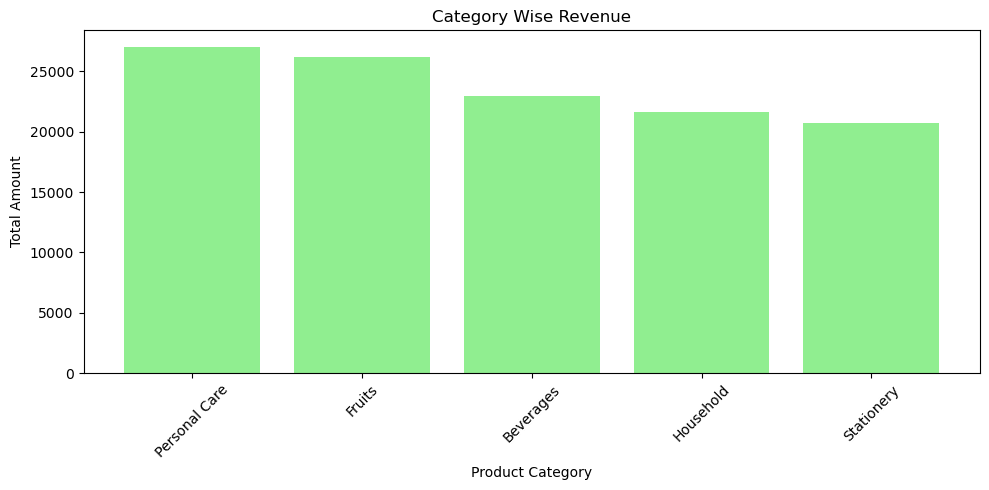

In [33]:
# Visual reprentation of the Category Wise revenue

category_revenue_plt = df.groupby("product_category")["total_price"].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
plt.bar(category_revenue_plt.index, category_revenue_plt.values, color = "lightgreen" )
plt.title("Category Wise Revenue")
plt.xlabel("Product Category")
plt.ylabel("Total Amount")
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

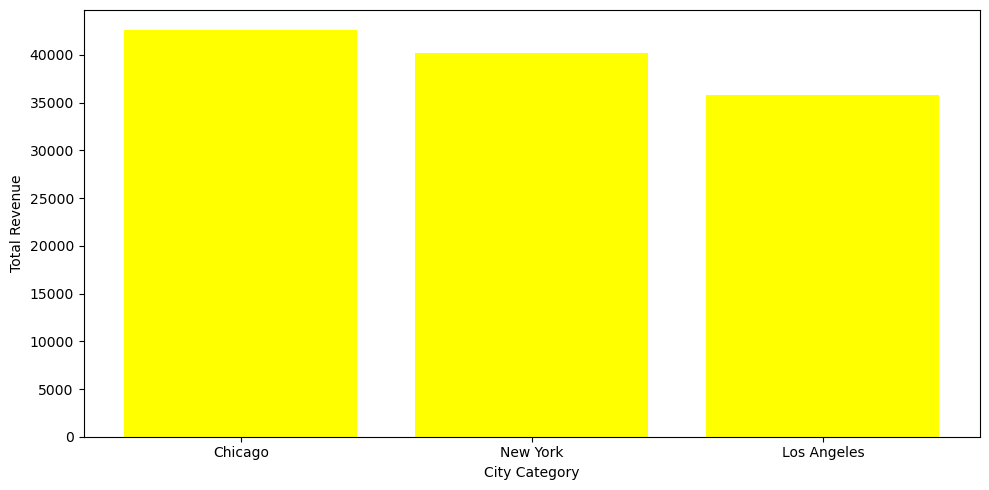

In [34]:
# Visual Representation of the City wise revenue

city_wise_revenue = df.groupby("city")["total_price"].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
plt.bar(city_wise_revenue.index, city_wise_revenue.values, color = "yellow")
plt.xlabel("City Category")
plt.ylabel("Total Revenue")
plt.tight_layout()
plt.show()

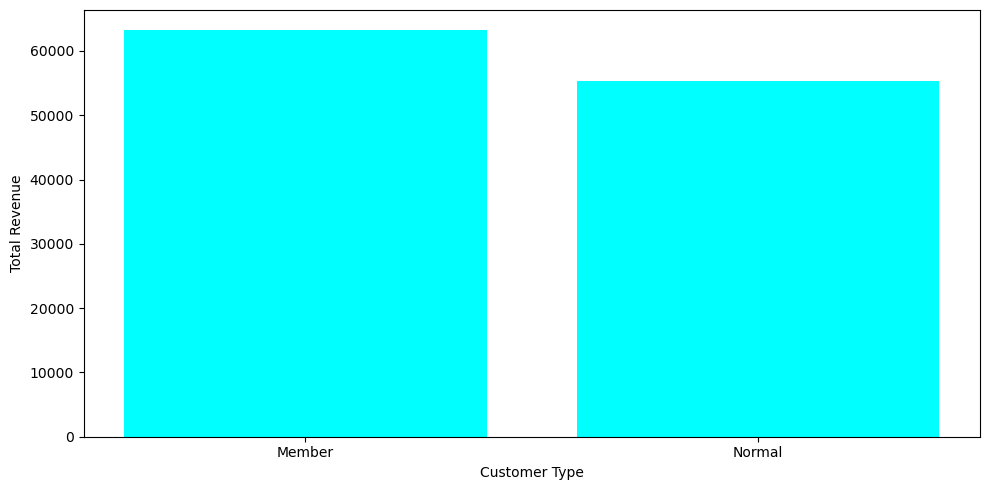

In [35]:
#customer wise revenue
customer_wise_revenue = df.groupby("customer_type")["total_price"].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
plt.bar(customer_wise_revenue.index, customer_wise_revenue.values, color = "aqua")
plt.xlabel("Customer Type")
plt.ylabel("Total Revenue")
plt.tight_layout()
plt.show()

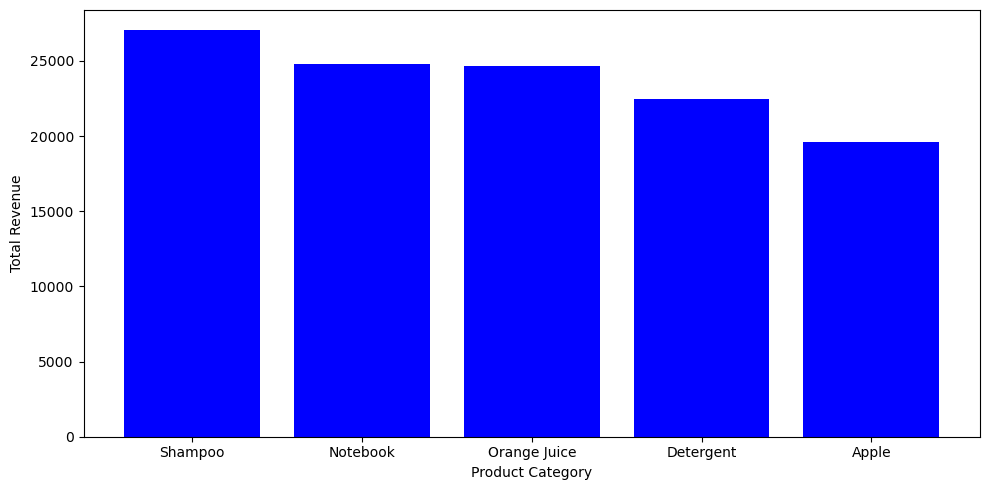

In [36]:
# Product Type wise Revenue

product_type_revenue = df.groupby("product_name")["total_price"].sum().sort_values(ascending=False)
plt.figure(figsize=(10,5))
plt.bar(product_type_revenue.index, product_type_revenue.values, color = "blue")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")
plt.tight_layout()
plt.show()

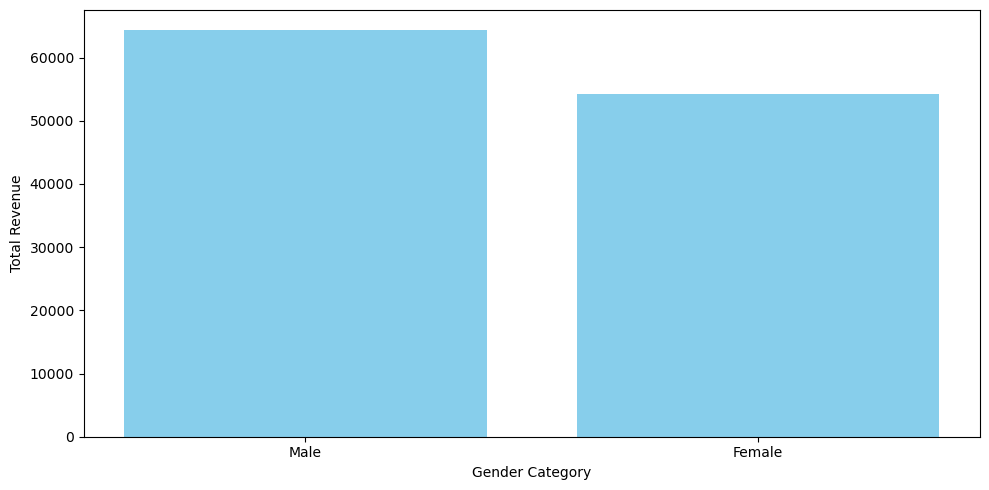

In [37]:
# Gender wise revenue

gender_wise_revenue = df.groupby("gender")["total_price"].sum().sort_values(ascending=False)
plt.figure(figsize=(10,5))
plt.bar(gender_wise_revenue.index, gender_wise_revenue.values, color = "skyblue")
plt.xlabel("Gender Category")
plt.ylabel("Total Revenue")
plt.tight_layout()
plt.show()

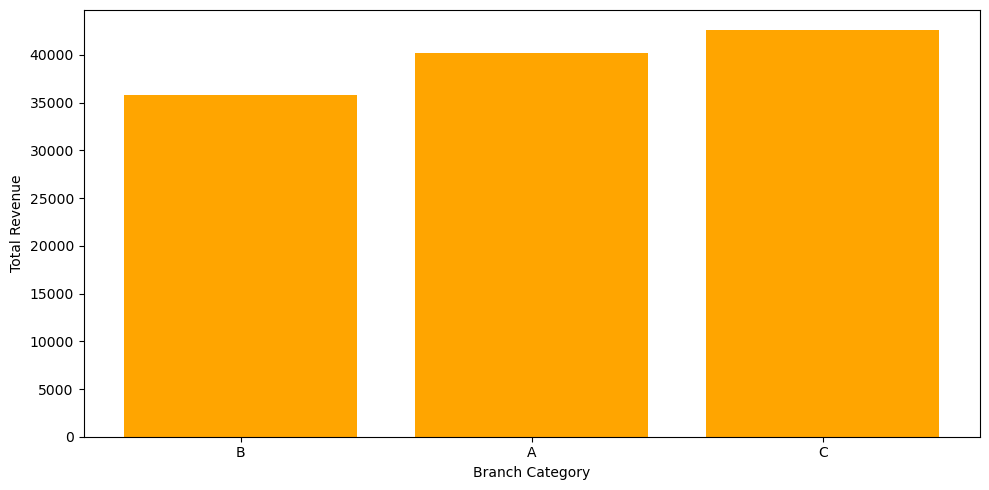

In [38]:
# Branch Wise Revenue

branch_wise_revenue = df.groupby("branch")["total_price"].sum().sort_values()
plt.figure(figsize=(10,5))
plt.bar(branch_wise_revenue.index , branch_wise_revenue.values, color = "orange")
plt.xlabel("Branch Category")
plt.ylabel("Total Revenue")
plt.tight_layout()
plt.show()